# Phase 1.5: Neural Network Feature Pipeline & PCA
This notebook takes the excellent domain-specific features generated in `02_feature_engineering.ipynb` and prepares them strictly for Deep Learning. 

**Steps:**
1. **Signed Log1p Transformation:** Applied to all monetary and volume columns to crush heavy tails (handling negative cash flows correctly).
2. **Zero-Inflation Flags:** Boolean indicators for absolute zero values.
3. **Standard Scaling:** Centering all continuous features to mean 0, std 1.
4. **PCA Class Overlap:** Visualizing the separability of Stressed vs Healthy users.
5. **Save to Parquet:** Ready for the PyTorch DataLoader.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Load Domain Features
print("Loading domain features...")
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
test_df = pd.read_parquet('../data/features/test_features.parquet', engine='fastparquet')

target_col = 'liquidity_stress_next_30d'
target = train_df[target_col]
train_df = train_df.drop(columns=[target_col, 'ID'], errors='ignore')
test_ids = test_df['ID']
test_df = test_df.drop(columns=['ID'], errors='ignore')

print(f"Train features shape: {train_df.shape}")
print(f"Test features shape: {test_df.shape}")

Loading domain features...
Train features shape: (40000, 228)
Test features shape: (30000, 228)


In [5]:
# 1 & 2: Log Transformation & Zero-Inflation Flags
# We use Signed Log1p to safely handle negative values like net_cash_flow
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def process_features(df):
    df_proc = df.copy()
    
    # Identify skewed numerical columns (amounts, volumes, flows, balances)
    skewed_cols = [c for c in df.columns if any(kw in c for kw in ['amount', 'value', 'volume', 'bal', 'flow', 'runway', 'peak', 'shock', 'volatility'])]
    
    for col in skewed_cols:
        if pd.api.types.is_numeric_dtype(df_proc[col]):
            # Create zero-inflation flag
            df_proc[f'{col}_is_zero'] = (df_proc[col] == 0).astype(int)
            
            # Apply signed log1p
            df_proc[col] = signed_log1p(df_proc[col])
            
    # Fill any remaining NaNs (e.g. from division by zero in earlier feature engineering) with 0
    df_proc = df_proc.fillna(0)
    
    # Convert categorical strings to categorical codes for Entity Embedding later
    cat_cols = [c for c in df_proc.columns if df_proc[c].dtype == 'object']
    for c in cat_cols:
        df_proc[c] = df_proc[c].astype('category').cat.codes
        
    return df_proc

print("Processing Train...")
X_train = process_features(train_df)
print("Processing Test...")
X_test = process_features(test_df)


Processing Train...


/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f'{col}_is_zero'] = (df_proc[col] == 0).astype(int)
/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f'{col}_is_zero'] = (df_proc[col] == 0).astype(int)
/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

Processing Test...


/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f'{col}_is_zero'] = (df_proc[col] == 0).astype(int)
/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f'{col}_is_zero'] = (df_proc[col] == 0).astype(int)
/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/1239108897.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [6]:
# 3. Standard Scaling (Continuous variables only)
bool_cols = [c for c in X_train.columns if X_train[c].nunique() <= 2 or 'is_zero' in c]
cont_cols = [c for c in X_train.columns if c not in bool_cols]

scaler = StandardScaler()
X_train[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test[cont_cols] = scaler.transform(X_test[cont_cols])

print("Scaling complete.")

Scaling complete.


Running PCA for visualization...


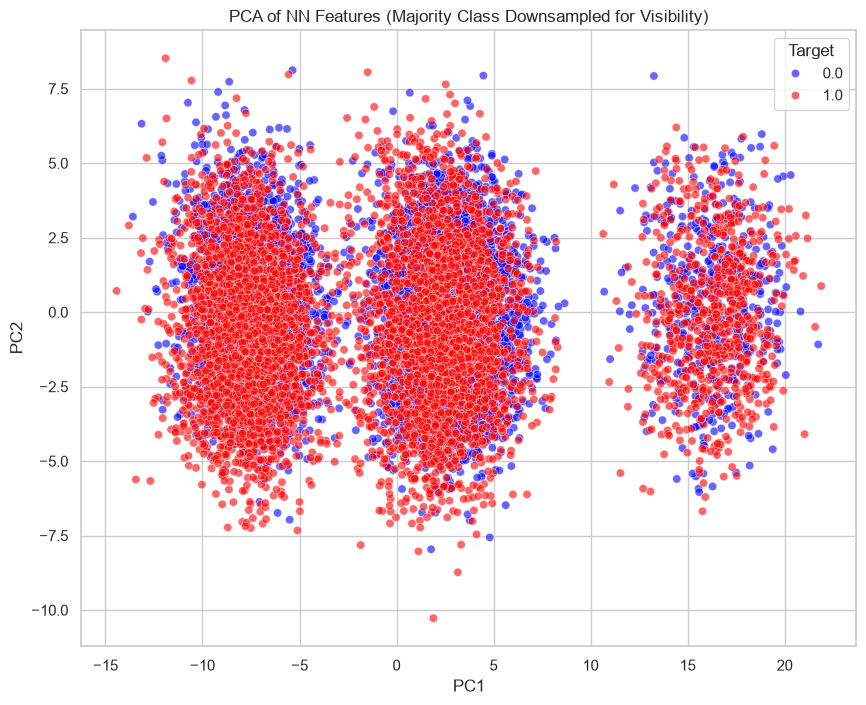

Explained variance by first 2 components: 24.09%


In [7]:
# 4. PCA Class Overlap Check
print("Running PCA for visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = target.values

# Downsample the majority class (0) so the minority class (1) isn't hidden
healthy = pca_df[pca_df['Target'] == 0].sample(frac=0.15, random_state=42) # Downsample to roughly match minority
stressed = pca_df[pca_df['Target'] == 1]
pca_plot_df = pd.concat([healthy, stressed])

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='Target', alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('PCA of NN Features (Majority Class Downsampled for Visibility)')
plt.show()

print(f"Explained variance by first 2 components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

In [8]:
# 5. Save to Parquet
print("Saving Neural Network ready features...")
X_train['liquidity_stress_next_30d'] = target.values
X_test['ID'] = test_ids.values

X_train.to_parquet('../data/features/train_nn_ready.parquet', index=False, engine='fastparquet')
X_test.to_parquet('../data/features/test_nn_ready.parquet', index=False, engine='fastparquet')
print("Saved successfully!")

Saving Neural Network ready features...


/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/3777613416.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['liquidity_stress_next_30d'] = target.values
/var/folders/c8/7krwwn3d4fq45_lf7twc4d7w0000gn/T/ipykernel_86356/3777613416.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['ID'] = test_ids.values


Saved successfully!
